# Gradients and Backpropagation

## Which little dial should we turn?

Imagine a small model that guesses how much water a plant needs. It takes a sensor reading, performs some calculations, and returns an amount. Our example's correct amount is one unit, but the model guesses two and a half.

A loss function can tell us how costly that mismatch is. It does not yet tell us what to change. The model has several adjustable numbers, called **parameters**. Think of them as little dials: turning one can change what happens farther along the calculation.

We need to know how the loss would respond to a tiny turn of each dial. A **gradient** collects those sensitivities. **Backpropagation** calculates them by following the model's operations backward, starting at the loss.

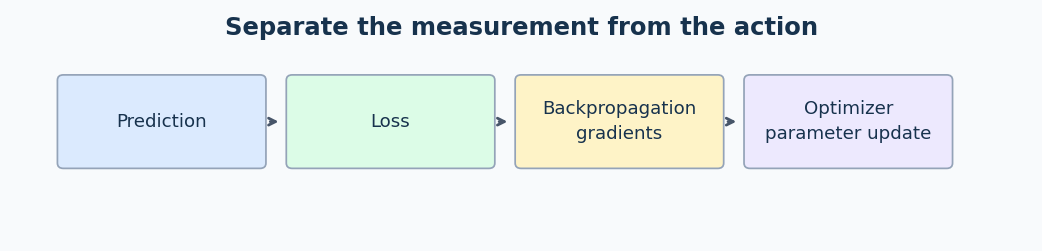

We will follow one small network all the way through, keeping every number visible. These are invented teaching values, not a watering system. The [code companion](07_Gradients_and_Backpropagation.ipynb) reproduces the arithmetic, compares it with PyTorch, and independently verifies it using tiny numerical changes.

## Start with the problem this lesson solves

A network made a wrong prediction, but many weights helped produce it. Which weights should change, in which direction, and by how much? Backpropagation answers the sensitivity part of that question by applying the chain rule backward through the forward calculation.

A gradient is a local rate of change of loss with respect to a parameter. It is not a new parameter value and not a moral assignment of blame. An optimizer uses these sensitivities to choose an update.

## Work forward, backward, and forward again

Use one training pair, input $x=2$ and target $y=1$. The hidden neuron has weight $w=0.5$ and bias $b=0.5$; the output has weight $v=2$ and bias $c=-0.5$.

**Forward calculation:**

$$z=wx+b=0.5(2)+0.5=1.5,$$
$$h=\max(0,z)=1.5,$$
$$\hat y=vh+c=2(1.5)-0.5=2.5,$$
$$L=\tfrac12(\hat y-y)^2=\tfrac12(2.5-1)^2=1.125.$$

The half is a convenient scaling choice: it cancels the two from differentiating a square. This is half squared error for one example, not the default scaling of PyTorch's MSE loss.

**Backward calculation, with each local multiplier visible:**

| Quantity | Reason | Loss derivative |
| --- | --- | --- |
| Prediction $\hat y$ | Derivative of half squared error is the error | $2.5-1=1.5$ |
| Output weight $v$ | Changing $v$ changes prediction by $h$ times that change | $1.5\times1.5=2.25$ |
| Output bias $c$ | It adds directly to prediction | $1.5\times1=1.5$ |
| Hidden output $h$ | Output multiplies $h$ by $v$ | $1.5\times2=3$ |
| Hidden score $z$ | ReLU's slope at positive 1.5 is one | $3\times1=3$ |
| Hidden weight $w$ | $z=wx+b$ has slope $x=2$ with respect to $w$ | $3\times2=6$ |
| Hidden bias $b$ | It adds directly to $z$ | $3\times1=3$ |

For example, $dL/dw=6$ says a sufficiently small increase $\Delta w$ changes loss by approximately $6\Delta w$, with other parameters fixed. It does not say that the weight equals six.

**Update all four parameters using their gradients at the old state.** With SGD rate $0.01$:

$$w'=0.5-0.01(6)=0.44,\quad b'=0.5-0.01(3)=0.47,$$
$$v'=2-0.01(2.25)=1.9775,\quad c'=-0.5-0.01(1.5)=-0.515.$$

**Repeat the forward pass:** $z'=0.44(2)+0.47=1.35$, so $h'=1.35$. The new prediction is $1.9775(1.35)-0.515=2.154625$. New loss is $\tfrac12(2.154625-1)^2\approx0.666579$, below $1.125$.

This is the complete learning mechanism on one example: predict, measure, differentiate, update, and predict again. The loss reduction is measured, not assumed; a larger step or another example could behave differently.

## Why passing gradients backward is useful

The output error can guide an early hidden weight even though that weight has no direct target. Backpropagation multiplies local sensitivities along paths and adds contributions when paths meet. Shared parameters therefore receive evidence from all their uses.

If this hidden score were negative, ReLU would give zero derivative along this path, preventing a local gradient update to its incoming weights from this example. Autograd follows the same mathematical rules automatically. Calling backward computes gradients; only a separate update changes parameters.

## A slope tells us what a small movement would do

Start with something simpler than a network: a number $w$ whose score is $f(w)=w^2$. The name $f$ means “the rule that squares its input.” At $w=3$, the score is nine.

Move the input to $3.01$. The new score is $3.01^2=9.0601$. A tiny input change of $0.01$ produced an output change of $0.0601$, about six times as much.

The **derivative** describes this rate of change as the input movement becomes arbitrarily small. We write it as $df/dw$, read “the derivative of $f$ with respect to $w$.” For squaring, the derivative is $2w$, so at three the slope is six.

| Quantity | Calculation | Meaning |
| --- | --- | --- |
| Small input change | $\Delta w=0.01$ | Turn the dial slightly upward |
| Slope at the starting point | $df/dw=6$ | Nearby output changes about six times as much |
| Estimated output change | $6\times0.01=0.06$ | What the local slope predicts |
| Actual output change | $9.0601-9=0.0601$ | Very close, but not exactly equal |

The symbol $\Delta$ means “change in.” The estimate is not exact because the slope itself changes as we move. This is what **local** means: a derivative describes the neighborhood of the current value, not the entire curve.

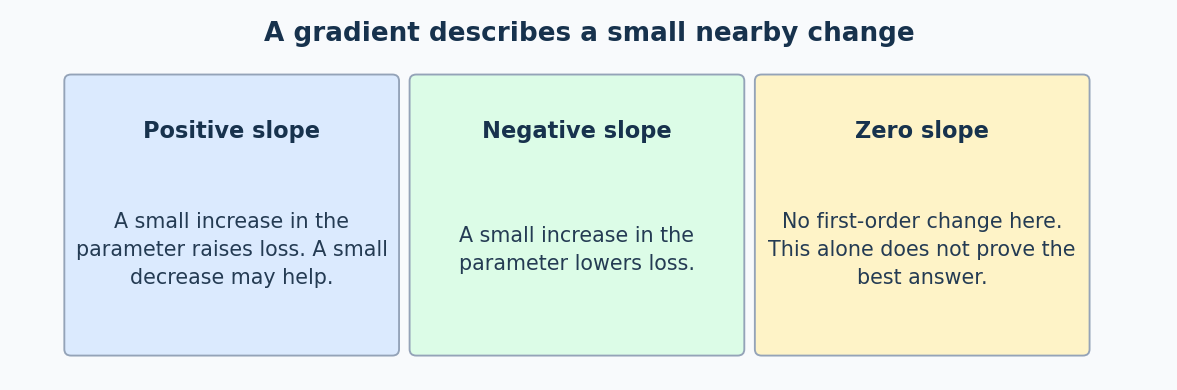

For a loss depending on several parameters, a **partial derivative** turns just one dial while holding the others fixed. We write $\partial L/\partial w$ for the loss sensitivity to $w$; $\partial$ marks this one-variable-at-a-time view. The **gradient** is the collection of these partial derivatives, arranged to match the parameters.

## Meet the small network and its adjustable numbers

Our input is $x=2$ and the target is $y=1$. The input is a sensor reading; the target is the desired output for this example. The model uses a hidden calculation before producing its prediction.

| Symbol | Meaning | Starting value |
| --- | --- | --- |
| $x$ | Input reading | 2 |
| $y$ | Target answer | 1 |
| $w$ | Weight multiplying the input | 0.5 |
| $b$ | Bias added to the hidden score | 0.5 |
| $v$ | Weight multiplying the hidden output | 2 |
| $c$ | Bias added to the prediction | -0.5 |

A **weight** multiplies a value, changing how strongly it contributes. A **bias** adds an offset. Here the parameters are $w,b,v,c$. The input and target describe the example rather than adjustable model settings.

The network uses **ReLU**, a rule that keeps positive numbers and replaces negative numbers with zero. Its name stands for rectified linear unit. It introduces a bend into an otherwise straight-line calculation.

We call the hidden score $z$, the value after ReLU $h$, and the prediction $\hat y$. The hat means “estimate.” These intermediate names help us follow how one calculation feeds another.

## Walk forward before walking backward

A **forward pass** calculates the model's answer and then its loss using the current parameter values.

| Stage | Rule | Substitute the numbers | Result |
| --- | --- | --- | --- |
| Hidden score | $z=wx+b$ | $0.5\times2+0.5$ | 1.5 |
| Hidden output | $h=\max(0,z)$ | Keep the larger of zero and 1.5 | 1.5 |
| Prediction | $\hat y=vh+c$ | $2\times1.5-0.5$ | 2.5 |
| Error | $\hat y-y$ | $2.5-1$ | 1.5 |
| Loss | $L=\tfrac12(\hat y-y)^2$ | $\tfrac12\times1.5^2$ | 1.125 |

We use **half the squared error**. Squaring makes either direction of error costly, and the factor of one-half keeps the derivative simple. It scales the loss without changing where its minimum lies. PyTorch's default mean squared error does **not** include this half factor; the companion writes it explicitly.

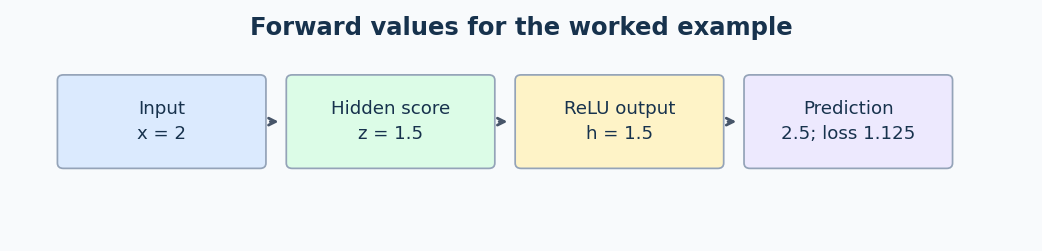

Keep the intermediate values nearby. A backward calculation uses them: for example, the sensitivity to the output weight depends on the hidden value it multiplied. Backpropagation follows this recorded calculation; it does not undo it to recover the input.

## Learn the small rules before joining them

Every operation has a local answer to “What if this input changed a tiny amount?”

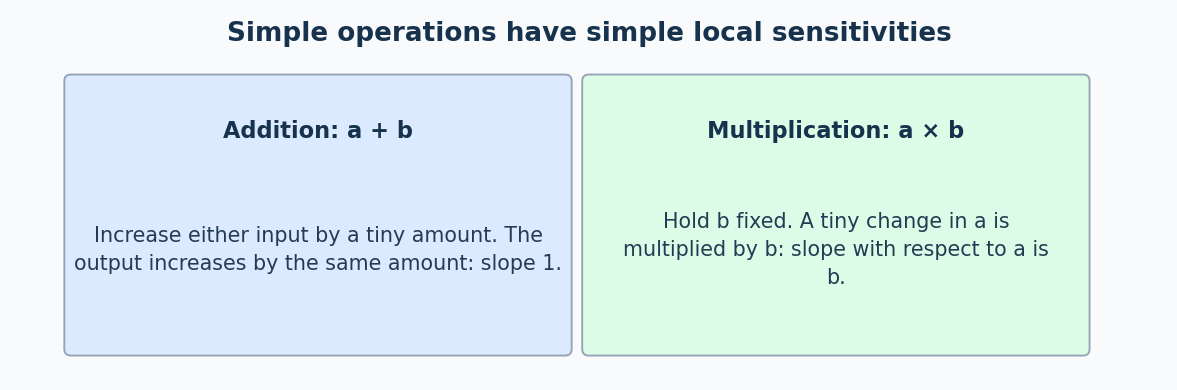

For $z=wx+b$, hold $x$ and $b$ fixed. Increasing $w$ by a tiny amount increases $z$ by $x$ times that amount. So $\partial z/\partial w=x$. Increasing $b$ adds directly to $z$, giving $\partial z/\partial b=1$.

| Operation | Local sensitivity | Why it has that value |
| --- | --- | --- |
| $z=wx+b$, change $w$ | $\partial z/\partial w=x$ | The input multiplies the weight's change |
| $z=wx+b$, change $b$ | $\partial z/\partial b=1$ | The bias is added directly |
| $h=\operatorname{ReLU}(z)$, with $z>0$ | $\partial h/\partial z=1$ | ReLU passes a positive value unchanged |
| $\hat y=vh+c$, change $h$ | $\partial\hat y/\partial h=v$ | The output weight scales the hidden change |

For our loss, its sensitivity to the prediction is the prediction error:

$$\frac{\partial L}{\partial\hat y}=\hat y-y.$$

Here is why. Call the error $r=\hat y-y$. Squaring has derivative $2r$, multiplying by one-half leaves $r$, and a change in the prediction changes $r$ by the same amount. At our current prediction, that slope is $1.5$.

## Join the little effects into one complete path

Suppose a small change is doubled by one operation and tripled by the next. Its final effect is six times as large: $2\times3=6$.

The **chain rule** uses this same idea for derivatives. If a parameter $w$ changes an intermediate value $u$, and that value changes the loss, then along that path:

$$\frac{\partial L}{\partial w}
=\frac{\partial L}{\partial u}\times\frac{\partial u}{\partial w}.$$

The first factor says how sensitive the loss is to $u$. The second says how sensitive $u$ is to $w$. Their product connects the starting dial to the final score.

What if the same dial affects the answer through two paths? Add the contributions. For example, if $u=2w$, $t=3w$, and $s=u+t$, changing $w$ has total sensitivity $2+3=5$ on $s$.

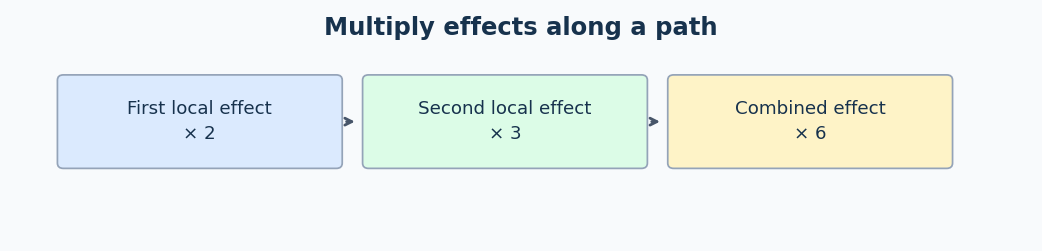

Backpropagation organizes these two rules across a **computation graph**, a map whose connections show which operations depend on which values. It calculates a sensitivity once and reuses it for earlier operations that need it. That reuse makes it practical when a network has many parameters.

## Start at the loss and move through the output

Our loss sensitivity to the prediction is $1.5$. That is the backward signal arriving at the output calculation $\hat y=vh+c$.

Hold the hidden value fixed while turning the output-weight dial. A change in $v$ gets multiplied by $h=1.5$. The loss sensitivity to $v$ is therefore:

$$\frac{\partial L}{\partial v}
=\frac{\partial L}{\partial\hat y}\frac{\partial\hat y}{\partial v}
=1.5\times1.5=2.25.$$

The output bias $c$ enters by addition, so its local factor is one. To continue toward the hidden value, the local factor is the output weight $v=2$.

| Where the backward signal goes | Incoming loss sensitivity | Local factor | Result |
| --- | --- | --- | --- |
| Output weight $v$ | 1.5 | $h=1.5$ | $\partial L/\partial v=2.25$ |
| Output bias $c$ | 1.5 | 1 | $\partial L/\partial c=1.5$ |
| Hidden value $h$ | 1.5 | $v=2$ | $\partial L/\partial h=3$ |

The last row is not another parameter update. It is the signal we need to carry the calculation farther backward. We have learned how the loss responds to $h$; now we can ask how $h$ depends on the earlier parameters.

## Carry the signal through the hidden unit

ReLU received $z=1.5$, a positive score. Around that value it acts like a straight wire: a tiny change in $z$ produces the same change in $h$. Its local derivative is one, so the incoming signal of three stays three.

The hidden score is $z=wx+b$. The input $x=2$ multiplies changes in $w$, while changes in $b$ pass straight through.

| Destination | Calculation | Loss sensitivity |
| --- | --- | --- |
| Hidden score $z$ | $3\times1$ | 3 |
| Hidden weight $w$ | $3\times x=3\times2$ | 6 |
| Hidden bias $b$ | $3\times1$ | 3 |
| Input $x$ | $3\times w=3\times0.5$ | 1.5 |

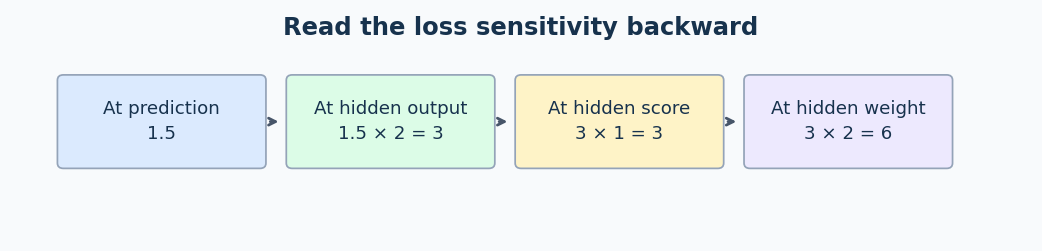

The complete parameter gradient, in the order $(w,b,v,c)$, is:

$$\nabla L=(6,3,2.25,1.5).$$

The symbol $\nabla L$, read “gradient of the loss,” is shorthand for that collection. For example, changing only $w$ by $0.001$ predicts a loss change of about $6\times0.001=0.006$ near the current parameters.

We also found the input sensitivity. That describes what would happen if the input changed; computing it does not mean the model changes its sensor reading. Likewise, these derivatives describe this mathematical calculation, not proof of cause and effect in a real greenhouse.

## Use the measurement to make a separate small move

All four parameter gradients are positive here. Small increases tend to raise this example's loss, so we can try small decreases.

A simple **gradient step** subtracts a small multiple of the gradient from each parameter:

$$\theta_{\mathrm{new}}=\theta_{\mathrm{old}}-\eta\nabla L.$$

$\theta$ names the collection of parameters. The positive number $\eta$, pronounced “eta,” is the **learning rate**, or step size. It controls how far we move in the direction suggested by the gradient.

With $\eta=0.01$, using all gradients from the original forward pass:

| Parameter | Old value | Subtract step size × gradient | New value |
| --- | --- | --- | --- |
| $w$ | 0.5 | $0.01\times6=0.06$ | 0.44 |
| $b$ | 0.5 | $0.01\times3=0.03$ | 0.47 |
| $v$ | 2 | $0.01\times2.25=0.0225$ | 1.9775 |
| $c$ | -0.5 | $0.01\times1.5=0.015$ | -0.515 |

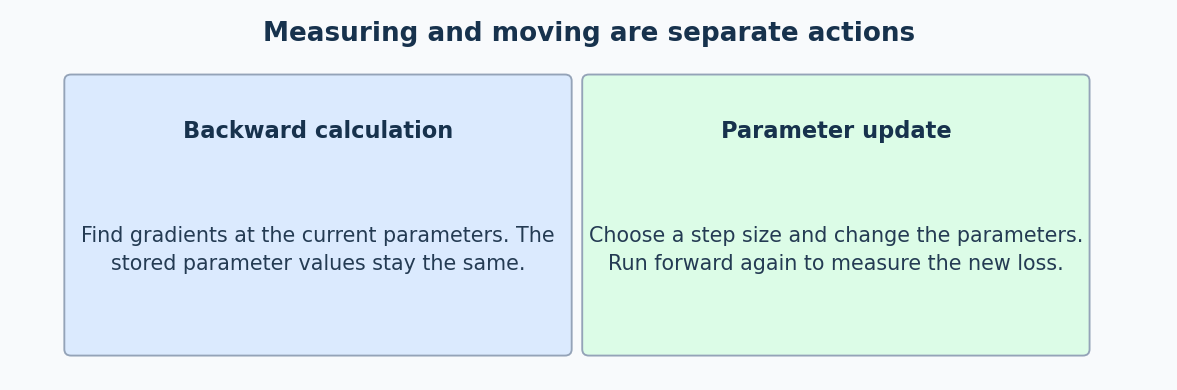

Run forward again: $z=0.44\times2+0.47=1.35$, so $h=1.35$. The prediction becomes $1.9775\times1.35-0.515=2.154625$. The new loss is about $0.666579$, below $1.125$.

This step helped on this example. A much larger move can fail because a local slope does not describe every point we might jump to. One improvement also does not prove that the model works on other examples. The companion keeps this as one explicit demonstration rather than claiming to train a useful system.

## See what happens when ReLU closes a path

Return to the **original** parameters, but change the input to $x=-2$. Now the hidden score is $0.5\times(-2)+0.5=-0.5$, so ReLU returns zero.

A tiny change that leaves the score negative still produces zero. The local slope is therefore zero, and multiplying by it stops the loss signal from reaching the hidden parameters through this path.

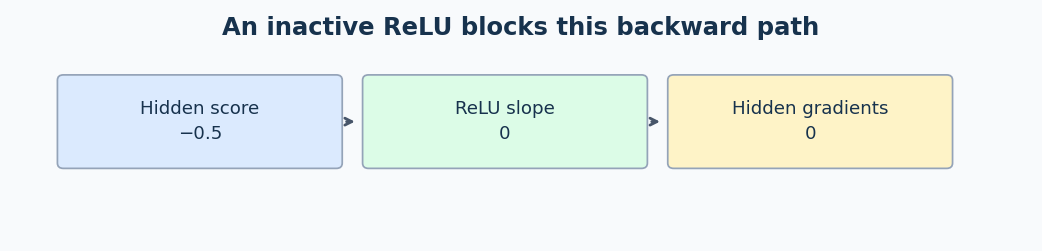

The prediction is now $2\times0-0.5=-0.5$, making the error $-1.5$.

| Parameter | Why its gradient has this value | Gradient |
| --- | --- | --- |
| Hidden weight $w$ | The hidden path includes ReLU's zero slope | 0 |
| Hidden bias $b$ | The same zero slope blocks this path | 0 |
| Output weight $v$ | It multiplies the hidden value, which is zero | 0 |
| Output bias $c$ | It still directly changes the prediction | -1.5 |

Zero gradients do not mean the prediction is correct: the loss is still $1.125$. They say that these particular parameter directions have no first-order effect at this point. Another input can activate the hidden unit and produce different gradients.

At exactly zero, ReLU has a corner: its left and right slopes differ, so there is no ordinary derivative there. PyTorch uses zero as its gradient convention at that point. Our worked inputs avoid the corner.

## Let several examples contribute to shared parameters

A **batch** is a group of examples processed together. Each uses the same model parameters, but can make a different contribution to their gradients.

Use the original parameters for examples A with $(x,y)=(2,1)$ and B with $(x,y)=(1,0)$. For B, the hidden value is one, the prediction is $1.5$, and the error is $1.5$. Applying the same local rules gives:

| Example | Gradient for $w$ | Gradient for $b$ | Gradient for $v$ | Gradient for $c$ |
| --- | --- | --- | --- | --- |
| A | 6 | 3 | 2.25 | 1.5 |
| B | 3 | 3 | 1.5 | 1.5 |
| Mean of both | 4.5 | 3 | 1.875 | 1.5 |

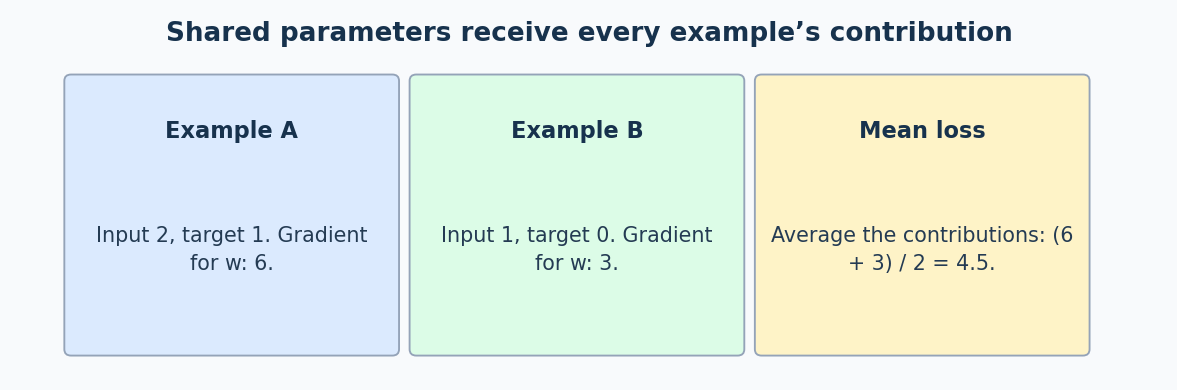

For a mean loss $L=(L_A+L_B)/2$, its gradient is the mean of the two individual gradients. More generally, with $N$ examples, add their gradients and divide by $N$. For a summed loss, add without dividing.

This is the “add contributions from shared paths” rule in action. Examples can even push in opposite directions. The combined gradient reflects the specified combined loss, not a promise to improve every example individually.

## Ask PyTorch to follow the same calculation

PyTorch's **autograd**, short for automatic differentiation, records supported operations involving tensors that require gradients. It then applies the local derivative rules through their computation graph. It does not need to estimate each derivative by repeatedly nudging a parameter.

The companion creates parameters with `requires_grad=True`. Calling `loss.backward()` starts from the scalar loss and accumulates the resulting parameter derivatives into `.grad`.

| Code term | Plain meaning | Why the companion uses it |
| --- | --- | --- |
| `requires_grad=True` | Track how this tensor affects later calculations | Make derivatives available for parameters and the input |
| Leaf tensor | A starting tensor created directly rather than computed from another tracked tensor | Its `.grad` normally receives the accumulated derivative |
| `retain_grad()` | Also keep the gradient of an intermediate tensor | Display sensitivities for $z$, $h$, and the prediction |
| `detach()` | Make a tensor view disconnected from earlier gradient history | Keep manual arithmetic separate from autograd |
| `clone()` | Copy the values into separate storage | Preserve a snapshot; `detach()` alone shares storage |
| `no_grad()` | Stop recording operations inside a block | Useful when changing or inspecting values without building a gradient graph |

`backward()` computes derivatives; it does not update the parameters. The companion compares their values before and after to make that distinction visible.

Intermediate gradients are normally omitted from `.grad` to avoid retaining unnecessary data. The backward computation can still use those intermediates; `retain_grad()` only keeps their final sensitivities available for inspection.

A usual backward pass releases saved information needed to traverse that same graph again. The demonstrations build a fresh forward calculation whenever they need a fresh graph. If an output contains several values instead of one scalar loss, choose a reduction such as a mean, or supply an explicit incoming gradient specifying how those output sensitivities should be combined.

## Remember that stored gradients accumulate

A **buffer** is a place where a program keeps a value for later use. A parameter's `.grad` is an accumulating buffer: another backward calculation adds to what is already there.

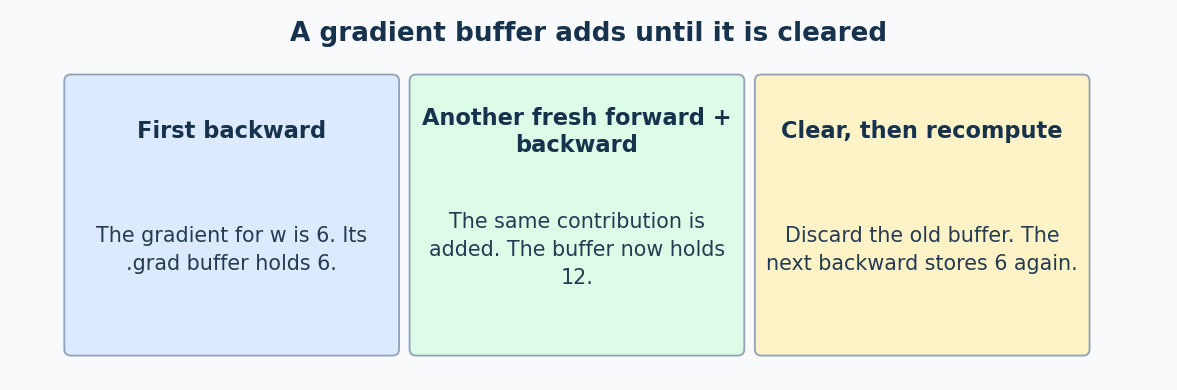

For the original example, the gradient for $w$ is six. Run a fresh forward and backward calculation again without changing parameters or clearing `.grad`, and its buffer becomes twelve. The derivative of one example has not changed; two copies of its contribution have been stored.

Setting `.grad = None` clears that stored value. The next backward calculation fills it with the newly computed gradient. Accumulation can be intentional when combining contributions, but old values should not accidentally enter an independent calculation.

There is another way to lose the intended connection: using a detached value, or converting a tensor to a Python number with `.item()` and then using that number in the loss. That later calculation cannot trace back through the removed history. `.item()` is useful for printing; it should not replace a tracked tensor along a path whose derivative we need.

## Verify the gradient by nudging one dial

We can independently approximate a derivative without using backpropagation. Hold every other parameter fixed, move $w$ a little above its current value, then a little below, and compare the losses:

$$\frac{\partial L}{\partial w}\approx
\frac{L(w+\varepsilon)-L(w-\varepsilon)}{2\varepsilon}.$$

The small positive number $\varepsilon$, pronounced “epsilon,” is the nudge size. This is a **central difference**: the numerator measures the change in loss between the two sides, and the denominator is the distance between those parameter values.

| With the original network | Value |
| --- | --- |
| Nudge size $\varepsilon$ | 0.001 |
| Loss at $w=0.501$ | 1.131008 |
| Loss at $w=0.499$ | 1.119008 |
| Estimated slope | $(1.131008-1.119008)/0.002=6$ |

That agrees with our gradient for $w$. The companion repeats the procedure for every parameter with a smaller nudge and double-precision numbers, which store more numerical detail than ordinary single precision. It checks that the numerical, manual, and autograd answers agree within a small rounding tolerance.

Too large a nudge can cross regions with different slopes; too small a nudge can lose accuracy when nearly equal stored numbers are subtracted. Near ReLU's corner, a central difference may also disagree with the library's chosen gradient convention.

Numerical nudges need separate forward evaluations for every parameter. Backpropagation shares the work across the graph, making it far more efficient for large networks.

## Understand what the backward calculation can tell us

The network carries values forward and sensitivities backward. Along a path, local sensitivities multiply. Where paths contribute to the same value, their contributions add. Together, those rules explain every gradient in our example.

| Observation | What it means | What it does not establish |
| --- | --- | --- |
| A nonzero gradient | A local direction affects this loss | That a large move will help |
| A zero gradient | No first-order change along that direction here | That the task is solved |
| Agreement with numerical nudges | The derivative matches a nearby numerical calculation | That the data or loss expresses the right task |
| A lower loss after one update | This change improved this measured objective | That predictions work on unseen examples |

Multiplication also explains why long paths can become difficult. Repeated factors smaller than one in magnitude can make a signal shrink; repeated large factors can make it grow. These effects are called **vanishing** and **exploding gradients**. The path's local derivatives determine the behavior; depth alone does not guarantee either problem.

Our calculation answers a precise question: how sensitive is this loss to these values at this point? That is useful information for changing a model, provided the computation, targets, and chosen loss represent what we actually want it to learn.

## Vectorized backpropagation through dense layers

Let rows be examples: $Z^{[l]}=A^{[l-1]}W^{[l]T}+b^{[l]}$ and $A^{[l]}=f(Z^{[l]})$. Define $\Delta^{[l]}=\partial L/\partial Z^{[l]}$. For a batch-mean loss, $\partial L/\partial W^{[l]}=\Delta^{[l]T}A^{[l-1]}/B$, $\partial L/\partial b^{[l]}=\sum_i\Delta_i^{[l]}/B$, and $\partial L/\partial A^{[l-1]}=\Delta^{[l]}W^{[l]}$. At the output, $\Delta^{[L]}$ is the loss derivative with respect to the output pre-activation; for softmax cross-entropy it simplifies to `(probabilities - one_hot) / B`, while other losses or output activations require the general chain rule. At a hidden layer, $\Delta^{[l]}=(\Delta^{[l+1]}W^{[l+1]})\odot f'(Z^{[l]})$. These formulas are the same scalar chain rule applied to every row and unit.